In [1]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
from scipy.ndimage import gaussian_filter
from skimage.restoration import richardson_lucy
import cv2

In [2]:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'

folder_name1 = 'basmatiriisi/'
file_number1 = '040'

folder_name2 = 'kuivahiiva/'
file_number2 = '042'

folder_name3 = 'seesaminsiemen/'
file_number3 = '044'

folder_name4 = "rikottu_ohrasuurimo/"
file_number4 = "036"

In [ ]:
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def openImage(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = openImage(paths['raw'])
    white, _ = openImage(paths['white'])
    dark, _  = openImage(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def create_sample_mask(cube, band=None):
    if band is None:
        band = minMaxReflectance(cube, False)[1]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    plt.imshow(mask)
    plt.show()
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask
    # Rajaa kuvan vain maskiin.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def minMaxReflectance(cube, draw=True):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    if draw:
        plt.subplot(1, 2, 1)
        plt.imshow(cube[:,:,8])
        plt.subplot(1, 2, 2)
        plt.imshow(cube[:,:,155])
        plt.show()
    return min, max


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result

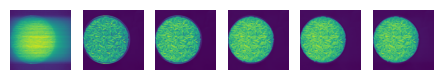

In [4]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 6

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()

In [19]:
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads

def processSample(path, folder_name, file_number, roi_mode="single", min_roi_area=50, margin=5, deblur = False, deblur_sigma=0.1, deblur_iter=5):
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    mask = create_sample_mask(processed)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
    else:
        processed = cube

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    spectrum = extract_mean_spectrum(segmented, roi_mask)

    return spectrum, waves